# The free library: 80,000 books from Project Gutenberg, in plain SQL

The catalogue of **Project Gutenberg**, the volunteer library of public-domain books: 79,533 items, 36,609 authors, 186,000 subject headings. The raw file packs authors, languages, subjects and bookshelves into semicolon-separated text, so the first job is to normalise it into proper tables (the build script does that). The queries then use joins across six tables, running totals and `LAG` for growth, conditional aggregation for language shares, life spans computed from author dates, a **self-join with lift** for subjects that go together, and a **recursive CTE** that splits book titles into words (SQLite has no string-split function). Python only runs the queries and draws the charts.

**Data:** the [Project Gutenberg catalogue](https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv) (a metadata file, about 21 MB, public domain). Run `python build_db.py` once to download it and build a SQLite database, then point `GUTENBERG_DB` at that file.

**Reading the data.** The *issue date* is when a book was added to Project Gutenberg, not when it was written. Some authors have no known dates (and "Various" and "Anonymous" are not people), so author-based questions cover only authors with dates. BCE years are negative.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("GUTENBERG_DB", "gutenberg.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,authors,36609
1,book_authors,110073
2,book_languages,79758
3,book_shelves,206269
4,book_subjects,185916
5,books,79533


## 1. How has the library grown?

Books are counted per year of addition, with a running total from `SUM() OVER (ORDER BY year)` and the year-on-year change from `LAG()`.

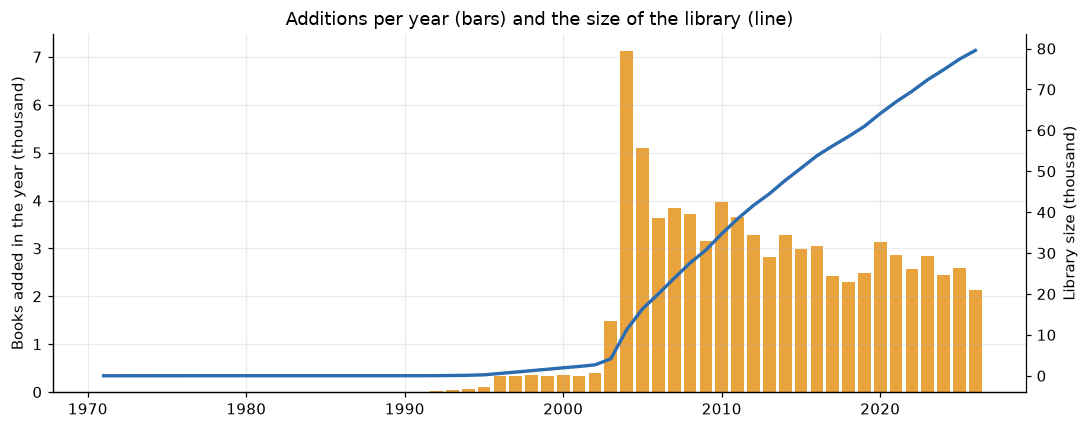

,year,added,texts,audiobooks,total_so_far,change_pct
22,2004,7118,6994,65,11265,381.0
23,2005,5099,4828,269,16364,-28.0
28,2010,3974,3974,0,34712,26.0
25,2007,3853,3568,285,23855,6.0
26,2008,3723,3631,92,27578,-3.0


In [3]:
growth = q("""
WITH yearly AS (
    SELECT CAST(substr(issued, 1, 4) AS INT) AS year,
           COUNT(*)                          AS added,
           SUM(type = 'Text')                AS texts,
           SUM(type = 'Sound')               AS audiobooks
    FROM books
    GROUP BY year
)
SELECT year, added, texts, audiobooks,
       SUM(added) OVER (ORDER BY year)                                            AS total_so_far,
       ROUND(100.0 * (added - LAG(added) OVER (ORDER BY year)) / LAG(added) OVER (ORDER BY year), 0) AS change_pct
FROM yearly
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(growth.year, growth.added / 1000, color=AMBER)
ax.set_ylabel("Books added in the year (thousand)")
ax2 = ax.twinx()
ax2.plot(growth.year, growth.total_so_far / 1000, color=BLUE, lw=2.2)
ax2.set_ylabel("Library size (thousand)")
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Additions per year (bars) and the size of the library (line)")
fig.tight_layout()
plt.show()
growth.sort_values("added", ascending=False).head(5)

## 2. Which languages does it hold?

Languages live in their own table (a book can have several), so a join to the books table and a window total give each language's share of all language links.

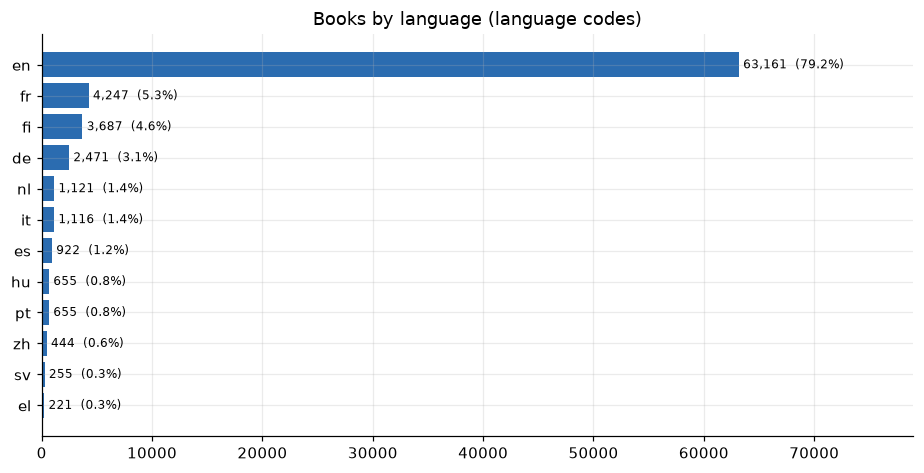

,language,books,share_pct,first_added
0,en,63161,79.2,1971
1,fr,4247,5.3,1997
2,fi,3687,4.6,2003
3,de,2471,3.1,1996
4,nl,1121,1.4,2001
5,it,1116,1.4,1997


In [4]:
languages = q("""
SELECT l.language,
       COUNT(*)                                           AS books,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
       MIN(CAST(substr(b.issued, 1, 4) AS INT))           AS first_added
FROM book_languages l
JOIN books b USING (book_id)
GROUP BY l.language
ORDER BY books DESC
LIMIT 12
""")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(languages.language[::-1], languages.books[::-1], color=BLUE)
for y, (v, s) in enumerate(zip(languages.books[::-1], languages.share_pct[::-1])):
    ax.text(v + 400, y, f"{v:,}  ({s}%)", va="center", fontsize=8)
ax.set_xlim(0, languages.books.max() * 1.25)
ax.set_title("Books by language (language codes)")
fig.tight_layout()
plt.show()
languages.head(6)

## 3. Is the library becoming less English?

Averaging a 0/1 flag over five-year periods of addition gives the share of books in languages other than English.

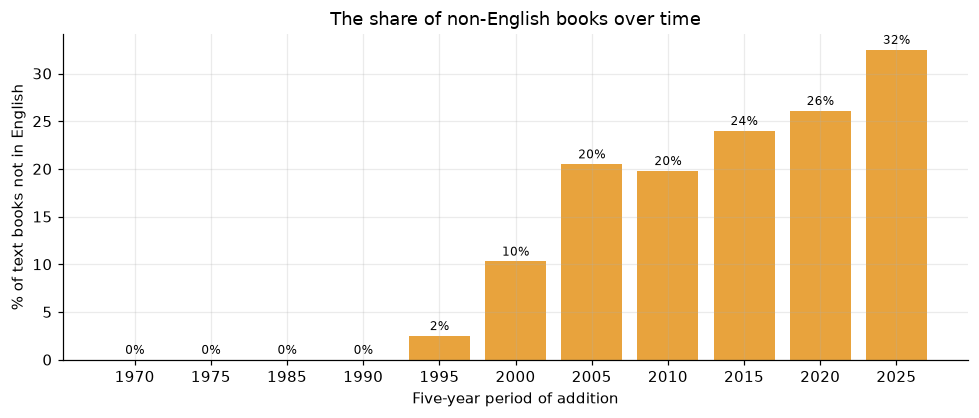

,period_from,book_languages,non_english_pct
0,1970,4,0.0
1,1975,5,0.0
2,1985,1,0.0
3,1990,105,0.0
4,1995,1463,2.5
5,2000,9379,10.3
6,2005,18665,20.5
7,2010,17064,19.8
8,2015,13250,24.0
9,2020,13857,26.1


In [5]:
mix = q("""
SELECT (CAST(substr(b.issued, 1, 4) AS INT) / 5) * 5      AS period_from,
       COUNT(*)                                            AS book_languages,
       ROUND(100.0 * AVG(l.language <> 'en'), 1)           AS non_english_pct
FROM books b
JOIN book_languages l USING (book_id)
WHERE b.type = 'Text'
GROUP BY period_from
ORDER BY period_from
""")

fig, ax = plt.subplots(figsize=(9, 3.9))
ax.bar(mix.period_from.astype(str), mix.non_english_pct, color=AMBER)
for x, v in enumerate(mix.non_english_pct):
    ax.text(x, v + 0.6, f"{v:.0f}%", ha="center", fontsize=8)
ax.set_ylabel("% of text books not in English")
ax.set_xlabel("Five-year period of addition")
ax.set_title("The share of non-English books over time")
fig.tight_layout()
plt.show()
mix

## 4. Who are the most prolific authors?

Three tables joined (`book_authors`, `authors`, `books`), with the non-person entries 'Various', 'Anonymous' and 'Unknown' excluded, and `RANK()` over the count.

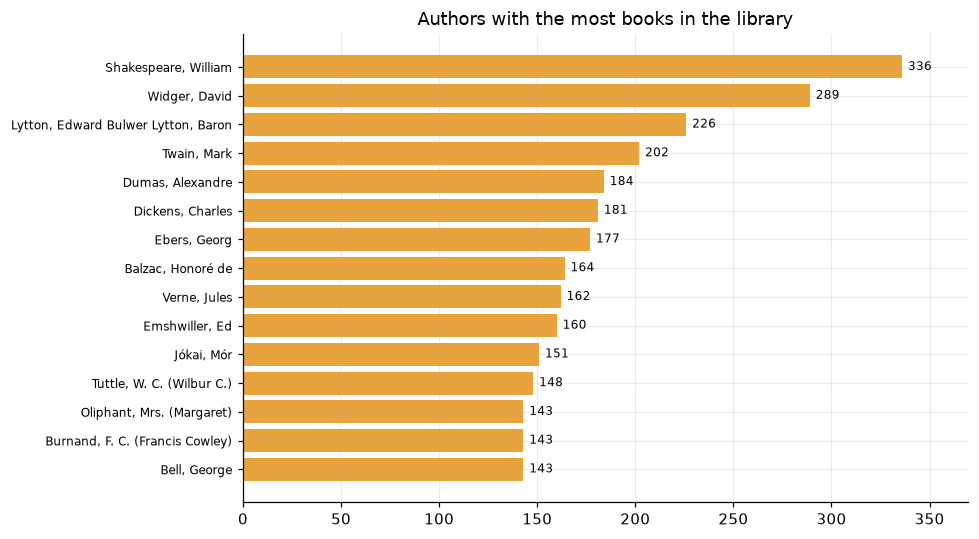

,name,books,birth_year,death_year
0,"Shakespeare, William",336,1564,1616
1,"Widger, David",289,1932,2021
2,"Lytton, Edward Bulwer Lytton, Baron",226,1803,1873
3,"Twain, Mark",202,1835,1910
4,"Dumas, Alexandre",184,1802,1870
5,"Dickens, Charles",181,1812,1870


In [6]:
authors = q("""
SELECT RANK() OVER (ORDER BY COUNT(*) DESC)               AS rank,
       a.name, a.birth_year, a.death_year,
       COUNT(*)                                            AS books,
       MIN(CAST(substr(b.issued, 1, 4) AS INT))            AS first_added,
       MAX(CAST(substr(b.issued, 1, 4) AS INT))            AS last_added
FROM book_authors ba
JOIN authors a USING (author_id)
JOIN books   b USING (book_id)
WHERE a.name NOT IN ('Various', 'Anonymous', 'Unknown') AND b.type = 'Text'
GROUP BY a.author_id
ORDER BY books DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(authors.name[::-1], authors.books[::-1], color=AMBER)
for y, v in enumerate(authors.books[::-1]):
    ax.text(v + 3, y, str(v), va="center", fontsize=8)
ax.set_xlim(0, authors.books.max() * 1.1)
ax.set_title("Authors with the most books in the library")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()
authors[["name", "books", "birth_year", "death_year"]].head(6)

## 5. When were the authors born?

Integer division (`birth_year / 10 * 10`) rounds each author's birth year down to a decade, and a join to the books counts how many books each decade of birth contributes.

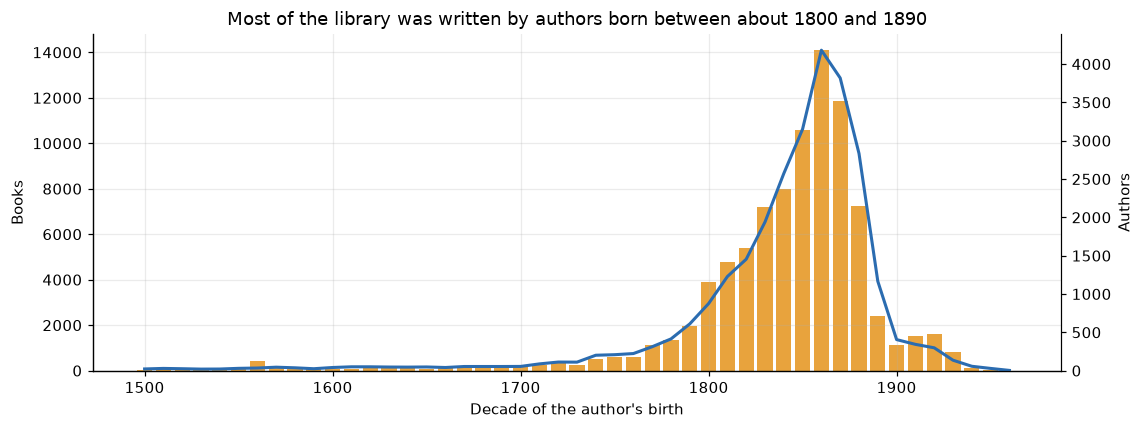

,birth_decade,authors,books
36,1860,4181,14094
37,1870,3818,11859
35,1850,3152,10582
34,1840,2572,7994
38,1880,2833,7226


In [7]:
births = q("""
SELECT (a.birth_year / 10) * 10     AS birth_decade,
       COUNT(DISTINCT a.author_id)  AS authors,
       COUNT(*)                     AS books
FROM authors a
JOIN book_authors ba USING (author_id)
WHERE a.birth_year BETWEEN 1500 AND 1960
GROUP BY birth_decade
ORDER BY birth_decade
""")

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.bar(births.birth_decade, births.books, width=8, color=AMBER, label="Books")
ax.set_ylabel("Books")
ax.set_xlabel("Decade of the author's birth")
ax2 = ax.twinx()
ax2.plot(births.birth_decade, births.authors, color=BLUE, lw=2, label="Authors")
ax2.set_ylabel("Authors")
ax2.set_ylim(0, None)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Most of the library was written by authors born between about 1800 and 1890")
fig.tight_layout()
plt.show()
births.sort_values("books", ascending=False).head(5)

## 6. Did authors live longer over the centuries?

Lifespan is `death_year - birth_year`, averaged per half-century of birth for authors with both dates (and a plausible span of 15 to 110 years). Authors born after 1900 are left out because many are still alive and have no death year.

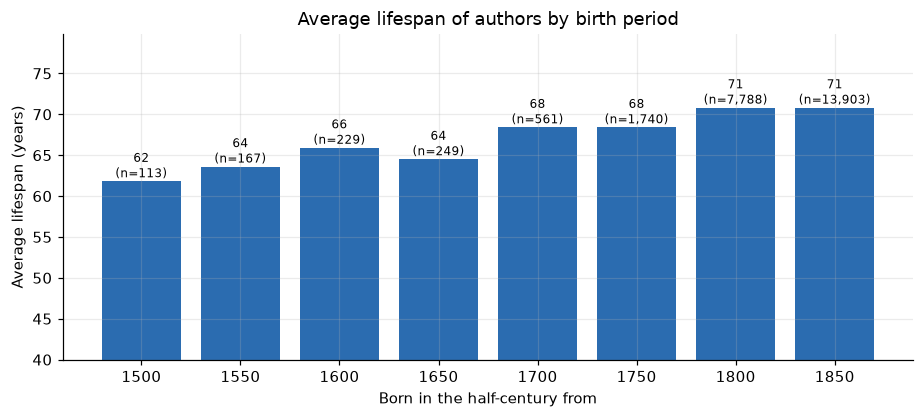

,born_from,authors,avg_lifespan,lived_to_80_pct
0,1500,113,61.8,13.3
1,1550,167,63.6,13.2
2,1600,229,65.9,16.2
3,1650,249,64.5,18.1
4,1700,561,68.4,22.5
5,1750,1740,68.4,24.9
6,1800,7788,70.8,28.0
7,1850,13903,70.8,30.2


In [8]:
lifespan = q("""
SELECT (birth_year / 50) * 50                                         AS born_from,
       COUNT(*)                                                       AS authors,
       ROUND(AVG(death_year - birth_year), 1)                         AS avg_lifespan,
       ROUND(100.0 * AVG(death_year - birth_year >= 80), 1)           AS lived_to_80_pct
FROM authors
WHERE birth_year BETWEEN 1500 AND 1899
  AND death_year IS NOT NULL
  AND death_year - birth_year BETWEEN 15 AND 110
GROUP BY born_from
ORDER BY born_from
""")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
ax.bar(lifespan.born_from.astype(str), lifespan.avg_lifespan, color=BLUE)
for x, (v, n) in enumerate(zip(lifespan.avg_lifespan, lifespan.authors)):
    ax.text(x, v + 0.5, f"{v:.0f}\n(n={n:,})", ha="center", fontsize=8)
ax.set_ylim(40, lifespan.avg_lifespan.max() + 9)
ax.set_xlabel("Born in the half-century from")
ax.set_ylabel("Average lifespan (years)")
ax.set_title("Average lifespan of authors by birth period")
fig.tight_layout()
plt.show()
lifespan

## 7. Which subjects go together?

Each subject heading is cut at the first ` -- ` (so 'United States -- History' becomes 'United States'). A **self-join** pairs the headings that appear on the same book among the 40 most common ones, and *lift* compares how often a pair occurs with how often it would if the headings were independent.

In [9]:
subjects = q("""
WITH main AS (
    SELECT DISTINCT book_id,
           CASE WHEN instr(subject, ' -- ') > 0 THEN substr(subject, 1, instr(subject, ' -- ') - 1) ELSE subject END AS heading
    FROM book_subjects
),
top AS (SELECT heading FROM main GROUP BY heading ORDER BY COUNT(*) DESC LIMIT 40),
pool AS (SELECT * FROM main WHERE heading IN (SELECT heading FROM top)),
total AS (SELECT COUNT(DISTINCT book_id) AS n FROM main),
single AS (SELECT heading, COUNT(*) AS c FROM pool GROUP BY heading),
pairs AS (
    SELECT x.heading AS a, y.heading AS b, COUNT(*) AS together
    FROM pool x
    JOIN pool y ON x.book_id = y.book_id AND x.heading < y.heading
    GROUP BY x.heading, y.heading
)
SELECT p.a AS heading_a, p.b AS heading_b, p.together AS books_together,
       ROUND(1.0 * p.together * t.n / (sa.c * sb.c), 1) AS lift
FROM pairs p
CROSS JOIN total t
JOIN single sa ON sa.heading = p.a
JOIN single sb ON sb.heading = p.b
WHERE p.together >= 40
ORDER BY lift DESC
LIMIT 12
""")

subjects

,heading_a,heading_b,books_together,lift
0,Children,Conduct of life,377,27.5
1,Conduct of life,Friendship,227,22.6
2,Christian life,Conduct of life,289,20.3
3,Children,Children's stories,113,19.6
4,Friendship,Girls,71,18.8
5,Children,Christian life,141,18.7
6,Love stories,Young women,177,17.7
7,Friendship,Voyages and travels,69,14.8
8,Children,Friendship,77,14.5
9,Conduct of life,Voyages and travels,167,13.9


## 8. What do the titles say? A recursive split

SQLite cannot split a string, but a **recursive CTE** can: each step peels the first word off the remaining title, until nothing is left. Applied to every English-language text it gives a word list to count. Punctuation and brackets are replaced by spaces and a short list of filler words is removed.

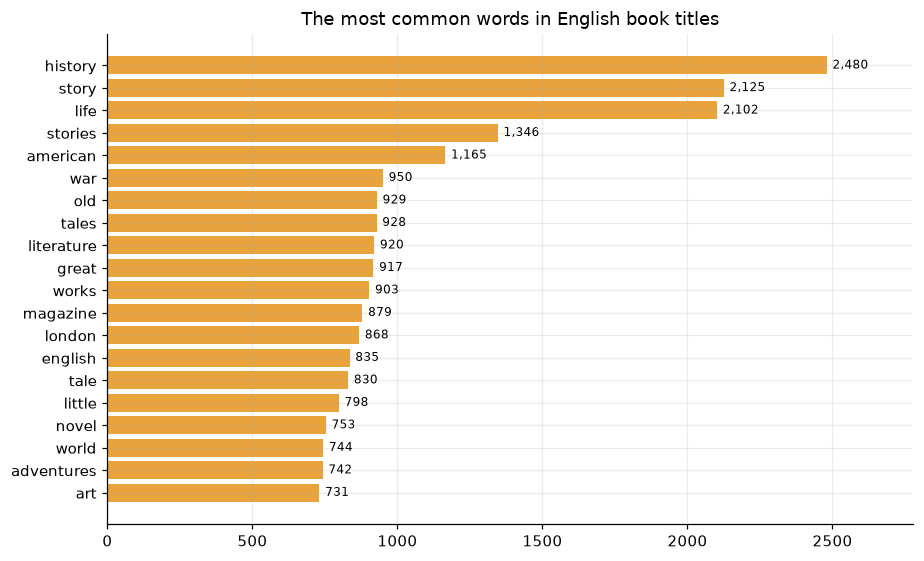

In [10]:
title_words = q("""
WITH RECURSIVE words(book_id, word, rest) AS (
    SELECT b.book_id, '',
           lower(replace(replace(replace(replace(replace(replace(replace(replace(replace(b.title, ',', ' '), ';', ' '), ':', ' '), '.', ' '), '-', ' '), char(10), ' '), '(', ' '), ')', ' '), '"', ' ')) || ' '
    FROM books b
    JOIN book_languages l USING (book_id)
    WHERE l.language = 'en' AND b.type = 'Text'
    UNION ALL
    SELECT book_id,
           substr(rest, 1, instr(rest, ' ') - 1),
           ltrim(substr(rest, instr(rest, ' ') + 1))
    FROM words
    WHERE rest <> ''
)
SELECT word, COUNT(DISTINCT book_id) AS titles
FROM words
WHERE length(word) > 2
  AND word NOT IN ('the','and','for','with','from','his','her','their','its','are','was','not','but','you','who','all','how','new','one','volume','vol','part','being','which','there','their','them','book','other','into','out','than','that','this','these','those','has','had','have','been','will','our','your')
GROUP BY word
ORDER BY titles DESC
LIMIT 20
""")

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh(title_words.word[::-1], title_words.titles[::-1], color=AMBER)
for y, v in enumerate(title_words.titles[::-1]):
    ax.text(v + 20, y, f"{v:,}", va="center", fontsize=8)
ax.set_xlim(0, title_words.titles.max() * 1.12)
ax.set_title("The most common words in English book titles")
fig.tight_layout()
plt.show()

## What the queries say

- **The library was built in a few bursts.** It held about 2,300 books at the end of 2001, then 7,118 were added in 2004 alone (the peak year), and it has added between 2,100 and 5,100 a year since. It now holds 79,533 items, and 2026 is a partial year (the latest addition is dated 4 October).
- **Four in five books are in English.** English has 63,161 books (79.2% of language links), followed by French (5.3%), Finnish (4.6%), German (3.1%), Dutch and Italian (1.4% each).
- **But the library is slowly becoming less English.** Among text books, the non-English share rose from 2.5% for books added in 1995-99 to 10% in 2000-04, 20% in 2005-09, 26% in 2020-24 and 33% in 2025-26 so far. The share is of book-language links, so a book in two languages counts twice.
- **Counts of books per author reward volume, not fame.** Shakespeare (336) leads, but second place is David Widger (289, born 1932, so not a classic author) and tenth is Ed Emshwiller (160, born 1925, better known as an illustrator). The catalogue stores a role such as "[Illustrator]" or "[Editor]" next to the name, and the build script removes it, so "author" here means "credited name". Lytton (226), Twain (202), Dumas (184) and Dickens (181) are the first real authors by volume after Shakespeare.
- **Most of the library comes from authors born between 1800 and 1890.** The peak decade is the 1860s, with 4,181 authors and 14,094 book credits, and the numbers drop quickly after the 1890s as copyright restrictions apply. Only 27,973 of the 36,609 authors have a birth year, so these counts cover about three quarters of the authors.
- **Authors born later lived longer.** Average lifespan rises from 62 years for authors born 1500-1549 to 71 years for those born 1800-1899, and the share who reached 80 rises from 13% to 30%. This is a sample of authors with both dates recorded (they are mostly well documented, which favours those who lived long enough to be remembered), so it should not be read as a population life expectancy. The earlier groups are also small (113 authors for 1500-49 against 13,903 for 1850-99).
- **Subject headings cluster tightly.** "Children" and "Conduct of life" appear together on 377 books, 27.5 times more often than independence would give, and "Children's stories" with "Fairy tales" 12.9 times. The pairs with the highest lift are moral and domestic subjects (conduct of life, friendship, girls, love stories), but lift is computed only among the 40 most common headings and says nothing about cause.
- **Titles are about stories and lives.** After removing filler words, "history" (2,480 titles), "story" (2,125) and "life" (2,102) are the most common words in English titles, followed by "stories", "american", "war" and "tales". "Magazine" appears in 879 titles, a reminder that periodicals are counted as books.

**Limits.** Issue dates show when a book entered the library, not when it was written. Authors with no dates are left out of the age and birth questions, and 165 author names contain a note such as "active 1850" that the parser does not interpret.
